# Color Cell IDs

Given an Excel spreadsheet indicating the cell type of each ID, a plot will be made of the tissue cross-section, where each cell type will have a different color.

The Excel spreadsheet must have one cell-type per column. Then each column will indicate the IDs to color. It is ok if different columns have different number of IDs. The column must also indicate the color corresponding to the cell type.

The background in the output figure will be white. Cells whose IDs was not indicated in any column will be colored gray.

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib as mpl
import tifffile as tf
import os
import utils

from scipy import ndimage, spatial,stats
viridis = mpl.colormaps['viridis'].resampled(4)

dst = os.pardir + os.sep + 'overlaps' + os.sep
dpi = 125
fs = 13.5
fmt = '.png'
savefigkw = dict(dpi=dpi, format=fmt[1:], bbox_inches='tight')

In [2]:
sample = 'D2'

wsrc = os.pardir + os.sep + 'cell_dams' + os.sep
#csrc = os.pardir + os.sep + 'data' + os.sep
#ksrc = os.pardir + os.sep + 'kde' + os.sep + sample + os.sep

wall = tf.imread(wsrc + sample + '_dams.tif').astype(bool)
wcoords = np.asarray(np.nonzero(~wall))
wallshape = wall.shape
label, cellnum = ndimage.label(wall, ndimage.generate_binary_structure(2,1))
label[label == 1] = 0
css = ndimage.find_objects(label)

ksrc = os.pardir + os.sep + 'kde' + os.sep + sample + os.sep
metacell = pd.read_csv(ksrc + sample + '_cells_metadata.csv', index_col = 'ndimage_cellID')
wc = np.loadtxt(ksrc + sample + '_icoords.csv', delimiter=',', dtype=int)
wc = wc[:, ~np.all(wc%50, axis=0)]
metaecc = pd.read_csv(ksrc + sample + '_nodule_root_eccentricity.csv', index_col='ndimage_cellID')
transcell = pd.read_csv(ksrc + sample + '_transcells_metadata_w_nucleus.csv', index_col='gene').rename(columns=int)
transcriptomes = np.asarray(transcell.index, dtype=str)
print(metacell.shape)
metacell.head()

(2937, 19)


,x0,x1,y0,y1,length,height,total_area,nuclei_area,cyto_area,c2t_area_ratio,orig_comX,orig_comY,ndimage_comX,ndimage_comY,orig_cellID,number_nuclei,total_volume,cyto_volume,nuclei_volume
ndimage_cellID,,,,,,,,,,,,,,,,,,,
1,0,17152,0,17152,17152,17152,114911591,36950,114874641,0.999678,7865.12,8160.49,7865.56,8160.76,1,0,4711375231,4709860281,1514950
2,8333,8935,1293,1979,602,686,222903,1351,221552,0.993939,8635.46,1576.65,8635.18,1577.03,2,1,9139023,9083632,55391
3,8893,9151,1317,1598,258,281,42604,0,42604,1.000000,9013.47,1470.26,9013.07,1469.69,3,0,1746764,1746764,0
4,10790,11221,1337,1591,431,254,77463,0,77463,1.000000,10999.04,1460.48,10998.62,1459.99,4,0,3175983,3175983,0
5,7740,8048,1362,1823,308,461,86041,870,85171,0.989889,7894.78,1596.06,7894.19,1595.83,5,1,3527681,3492011,35670


In [3]:
translocs = [None for _ in range(len(transcriptomes))]
src = os.pardir + os.sep + 'Bacteria Info for Erik' + os.sep
for i in range(len(transcriptomes)):
    filename = src + transcriptomes[i] + '_v2.txt'
    translocs[i] = pd.read_csv(filename, sep='\t')
tlocs = pd.concat(translocs)
tsutton = utils.generate_transcell_metadata(translocs, transcriptomes, cellnum, label).set_index('gene')

In [5]:
combined = tf.imread(wsrc + 'FINAL_cell_nuc_merged_uint32.tif')
combareas, _ = np.histogram(combined.ravel(), bins=np.arange(combined.max() + 2))

#noms = np.flip(np.asarray(ndimage.center_of_mass(lzw, lzw, range(1, lzw.max()+1))), axis=1)
#dists = spatial.distance.cdist(noms, metacell[['ndimage_comX','ndimage_comY']],  metric='euclidean')

In [6]:
nsrc = os.pardir + os.sep + 'nuclear_mask' + os.sep
nuclei = tf.imread(nsrc + sample + '_EDT.tif') < 1
lnuc, nnuc = ndimage.label(nuclei, ndimage.generate_binary_structure(2,1))
ns = ndimage.find_objects(lnuc)
nuc_area, _ = np.histogram(lnuc, bins=np.arange(nnuc + 2))
nuc_area[0] = 0
print('Detected',nnuc,'nuclei')

ynuclei = tf.imread(nsrc + 'FINAL_nuclei.tif')
ys = ndimage.find_objects(ynuclei)
ynuc_area, _ = np.histogram(ynuclei, bins=np.arange(ynuclei.max() + 2))
ynuc_area[0] = 0
print('Detected', ynuclei.max(),'nuclei')

Detected 1365 nuclei
Detected 2237 nuclei


In [125]:
ymethod = 'combined'
lzw = combined
newarea = combareas


#ymethod = 'nuclear'
#lzw = ynuclei
#newarea = ynuc_area


nss = ndimage.find_objects(lzw)
tyaohua = utils.generate_transcell_metadata(translocs, transcriptomes, lzw.max(), lzw).set_index('gene')

# Actual analyses



In [126]:
overlaps = dict()
overdf = pd.DataFrame(0., index=range(1,1+len(nss)), columns=['putative','TP','FP','FN','IoU', 'precision','recall','f1'])

for ix in overdf.index:
    newcell = lzw[nss[ix-1]] == ix
    intersect = label[nss[ix-1]][newcell]
    uq, ct = np.unique(intersect, return_counts=True)
    overlaps[ix] = np.vstack((uq[uq > 0], ct[uq > 0]))
    
    if overlaps[ix].shape[1] > 0:
        
        putative = overlaps[ix][0][ np.argmax(overlaps[ix][1]) ]
        
        overdf.loc[ix, 'putative'] = putative
        overdf.loc[ix, 'TP']  = overlaps[ix][1].max()
        overdf.loc[ix, 'FP'] = newarea[ix] - overdf.loc[ix, 'TP']
        overdf.loc[ix, 'FN'] = metacell.loc[putative, 'total_area'] - overdf.loc[ix, 'TP']
        overdf.loc[ix, 'IoU'] = overdf.loc[ix, 'TP']/overdf.loc[ix, ['TP','FP','FN']].sum()
        overdf.loc[ix, 'precision'] = overdf.loc[ix, 'TP']/newarea[ix]
        overdf.loc[ix, 'recall'] = overdf.loc[ix, 'TP']/metacell.loc[putative, 'total_area']
        

f1 = 2*overdf['precision']*overdf['recall']/(overdf['precision'] + overdf['recall'])
f1 = f1.fillna(0)
overdf['f1'] = f1
foo = ['putative', 'TP', 'FP', 'FN']
overdf = overdf.astype(dict(zip(foo, [int for _ in foo])))
matched = overdf.loc[overdf['putative'] > 0]
matched

,putative,TP,FP,FN,IoU,precision,recall,f1
1,2644,49928,1624,16417,0.734570,0.968498,0.752551,0.846977
2,2642,21472,2268,17090,0.525888,0.904465,0.556818,0.689288
3,2541,5546,3588,151688,0.034485,0.607182,0.035272,0.066671
4,2541,3899,2718,153335,0.024376,0.589240,0.024797,0.047592
5,2542,2804,3355,78250,0.033219,0.455269,0.034594,0.064302
...,...,...,...,...,...,...,...,...
3084,2903,424,491,28279,0.014524,0.463388,0.014772,0.028631
3085,2915,2322,0,48926,0.045309,1.000000,0.045309,0.086690
3087,296,610,924,37841,0.015492,0.397653,0.015864,0.030511
3088,803,544,266,110543,0.004885,0.671605,0.004897,0.009723


In [127]:
unmatched = overdf[overdf['putative'] == 0]
print('There are', len(overdf) - len(unmatched), 'matched Yaohua cells')
print('There are {} [{:.1f}%] unmatched Yaohua cells'.format(len(unmatched), len(unmatched)/len(overdf)*100))

duplicated = matched[ matched['putative'].duplicated(keep=False) ]
dupidx = []
for cidx in duplicated['putative'].unique():
    dupidx.append(matched[matched['putative'] == cidx ].sort_values('IoU').index[:-1])

dupidx = np.hstack(dupidx)
nondup = matched.drop(index=dupidx)

print('There are {} Yaohua cells in total'.format(len(overdf)))
print('There are {} [{:.1f}%] Yaohua matched to an already matched Sutton cell'.format(len(dupidx), len(dupidx)/len(overdf)*100))
print('Keeping only {} [{:.1f}%] Yaohua cells with unique Sutton-match'.format(len(nondup), len(nondup)/len(overdf)*100))
print('There are {} [{:.1f}%] Sutton cells with a unique Yaohua match'.format(len(nondup), len(nondup)/len(metacell)*100))
print('There are', len(metacell) - len(nondup), 'Sutton cells with no Yaohua match')

There are 3042 matched Yaohua cells
There are 47 [1.5%] unmatched Yaohua cells
There are 3089 Yaohua cells in total
There are 815 [26.4%] Yaohua matched to an already matched Sutton cell
Keeping only 2227 [72.1%] Yaohua cells with unique Sutton-match
There are 2227 [75.8%] Sutton cells with a unique Yaohua match
There are 710 Sutton cells with no Yaohua match


In [105]:
cidx = 2863
cidx = 2669
bar = matched[matched['putative'] == cidx ].sort_values('IoU')
bar

,putative,TP,FP,FN,IoU,precision,recall,f1


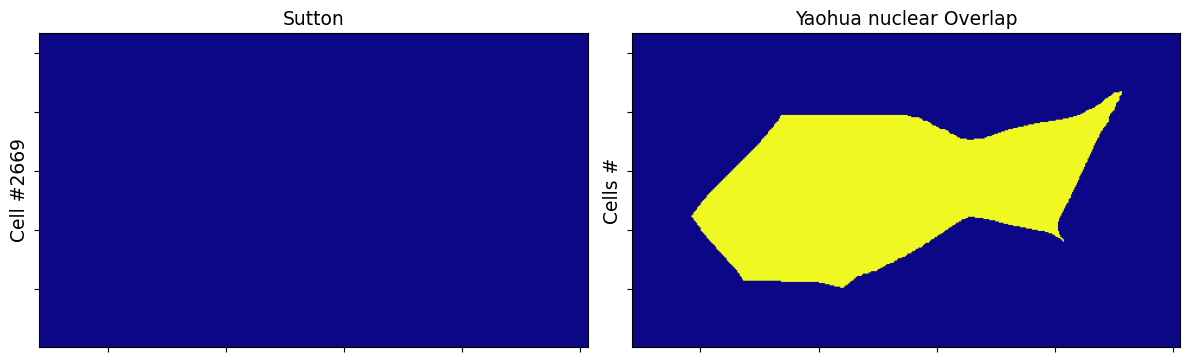

In [106]:
PP = 50
s_ = (np.s_[max([0, metacell.loc[cidx, 'y0'] - PP]) : min([label.shape[0], metacell.loc[cidx, 'y1'] + PP])],
      np.s_[max([1, metacell.loc[cidx, 'x0'] - PP]) : min([label.shape[1], metacell.loc[cidx, 'x1'] + PP])])
extent = (s_[1].start, s_[1].stop, s_[0].start, s_[0].stop)

bar = matched[matched['putative'] == cidx ]
foo = (label[s_] == cidx).copy().astype(np.uint8)

i = 1
for ix in bar.index:
    foo[ lzw[s_] == ix ] += 2*i
    i += 1

fig, ax = plt.subplots(1,2,figsize=(12,5), sharex=True, sharey=True)
ax[0].set_ylabel('Cell #{}'.format(cidx), fontsize=fs)
ax[1].set_ylabel('Cells #' + ', '.join(bar.index.astype(str)), fontsize=fs)
ax[0].imshow(label[s_] == cidx, extent=extent, vmin=0, vmax=min([5,len(bar)]), cmap='plasma')
ax[1].imshow(foo, extent=extent, cmap='plasma')
fig.tight_layout();
title = ['Sutton', 'Yaohua '+ymethod + ' Overlap']
for i in range(len(ax)):
    ax[i].set_title(title[i], fontsize=fs)
    ax[i].tick_params(labelleft=False, labelbottom=False)

fig.tight_layout()
plt.savefig(dst+'sutton_cell_{:04d}'.format(cidx)+fmt, **savefigkw)

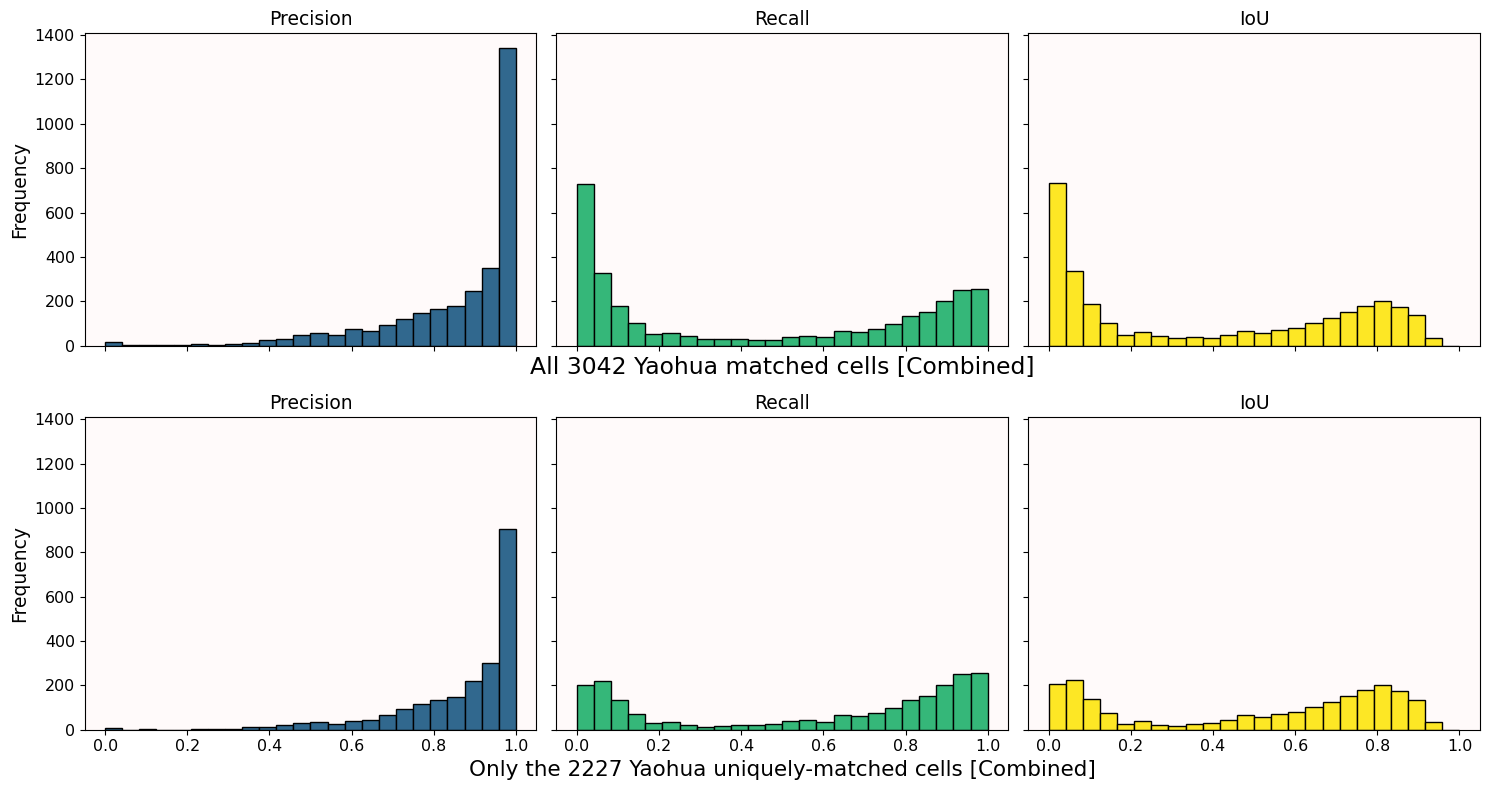

In [128]:
bins = np.linspace(0,1,25)
fig,ax = plt.subplots(2,3,figsize=(15,8), sharex=True, sharey=True)
for i,df in enumerate([matched, nondup]):
    for j,c in enumerate(['precision', 'recall', 'IoU']):
        ax[i,j].set_facecolor('snow')
        ax[i,j].set_title(c[0].upper() + c[1:], fontsize=fs)
        ax[i,j].hist(df[c], color=viridis(j+1), bins=bins, edgecolor='k')
        ax[i,j].tick_params(labelsize=0.85*fs)
    ax[i,0].set_ylabel('Frequency', fontsize=fs)
ax[0,1].set_xlabel('All {} Yaohua matched cells [{}]'.format(len(matched), ymethod.title()), fontsize=1.25*fs)
ax[1,1].set_xlabel('Only the {} Yaohua uniquely-matched cells [{}]'.format(len(nondup), ymethod.title()), fontsize=1.15*fs)
fig.tight_layout()

plt.savefig(dst + 'value_distribution_' + ymethod + fmt, **savefigkw)

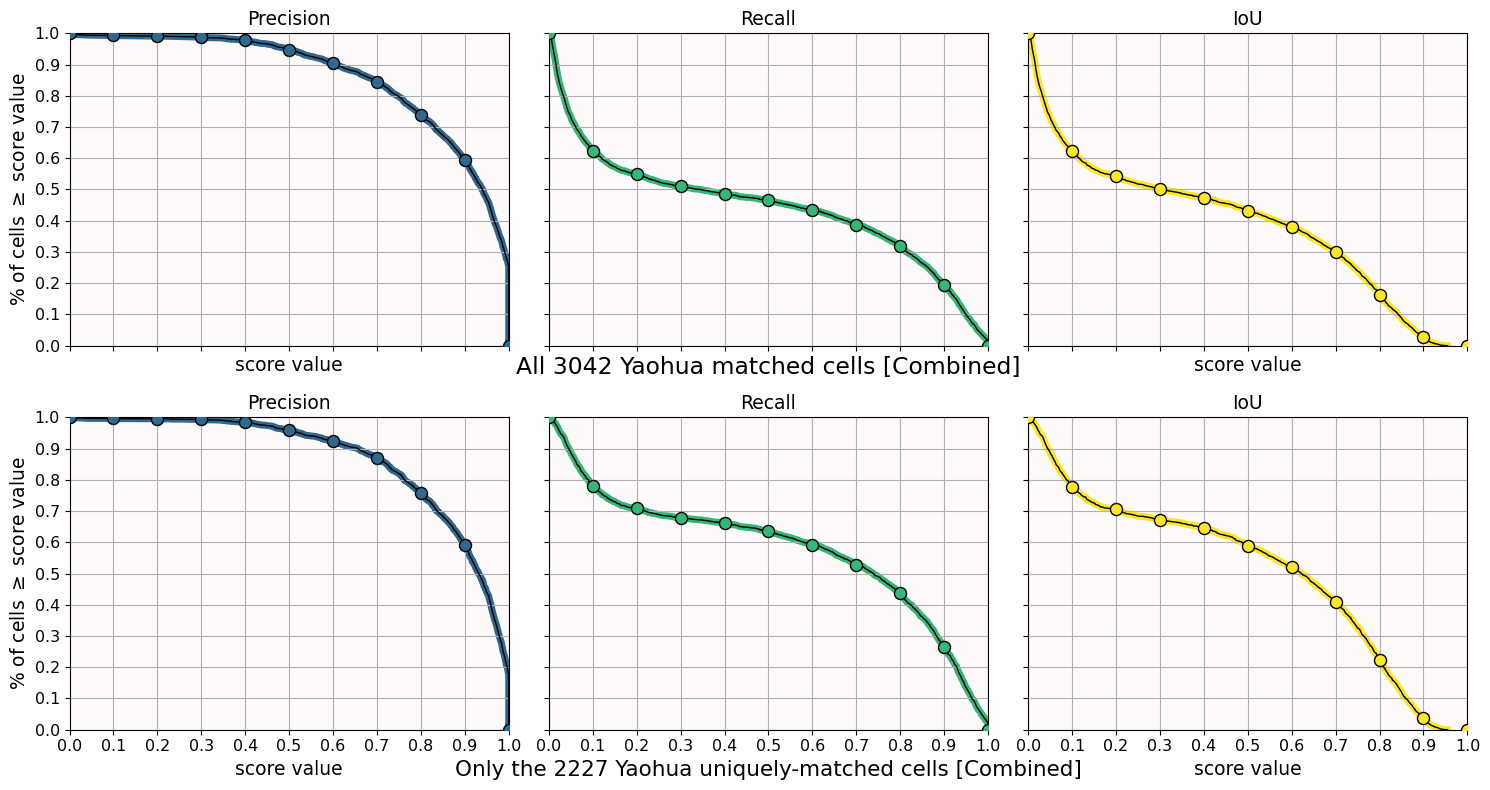

In [129]:
xvals = np.linspace(0,1,11)
fig,ax = plt.subplots(2,3,figsize=(15,8), sharex=True, sharey=True)
for i,df in enumerate([matched, nondup]):
    for j,c in enumerate(['precision', 'recall', 'IoU']):
        ecdf = stats.ecdf(df[c])
        
        ax[i,j].set_facecolor('snow')
        ax[i,j].set_title(c[0].upper() + c[1:], fontsize=fs)
        ax[i,j].plot(ecdf.cdf.quantiles, 1-ecdf.cdf.probabilities, c=viridis(j+1), lw=5, zorder=1)
        ax[i,j].plot(ecdf.cdf.quantiles, 1-ecdf.cdf.probabilities, c='k', lw=1, zorder=2)
        ax[i,j].scatter(xvals, 1-ecdf.cdf.evaluate(xvals), color=viridis(j+1), ec='k', zorder=3, s=75)
        ax[i,j].tick_params(labelsize=0.85*fs)
        ax[i,j].set_xticks(xvals, np.round(xvals,1) )
        ax[i,j].set_yticks(xvals, np.round(xvals,1) )
        ax[i,j].grid(which='major')
        ax[i,j].margins(0)
        ax[i,j].set_xlabel('score value', fontsize=fs)
    ax[i,0].set_ylabel('% of cells $\\geq$ score value', fontsize=fs)
ax[0,1].set_xlabel('All {} Yaohua matched cells [{}]'.format(len(matched), ymethod.title()), fontsize=1.25*fs)
ax[1,1].set_xlabel('Only the {} Yaohua uniquely-matched cells [{}]'.format(len(nondup), ymethod.title()), fontsize=1.15*fs)
fig.tight_layout()

plt.savefig(dst + 'ecdf_value_distribution_' + ymethod + fmt, **savefigkw)

In [110]:
df = nondup.copy()

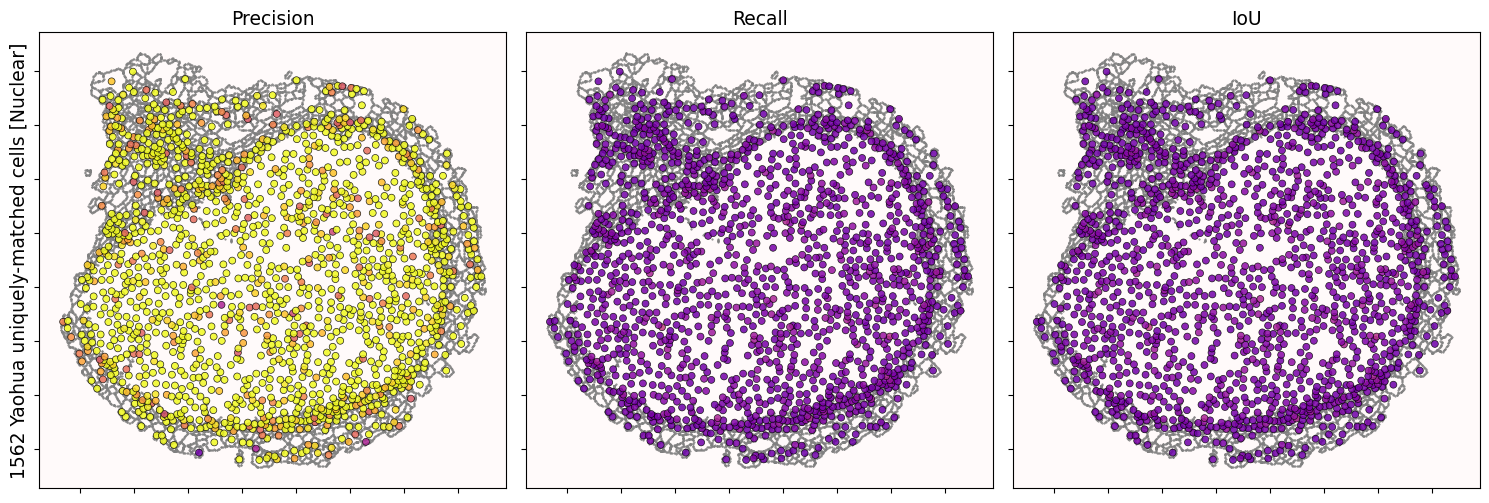

In [111]:
fig,ax = plt.subplots(1,3,figsize=(15,5), sharex=True, sharey=True)

for i,c in enumerate(['precision', 'recall', 'IoU']):
    ax[i].set_facecolor('snow')
    ax[i].scatter(wc[1], wc[0], marker='.', s=1, c='gray', zorder=1)
    ax[i].set_title(c[0].upper() + c[1:], fontsize=fs)
    ax[i].scatter(*metacell.loc[df['putative'].values, ['ndimage_comX','ndimage_comY']].T.values,
                  c = df[c], vmin=-.25, vmax=1, cmap='plasma', s=25, zorder=3, ec='k', lw=0.5, alpha=0.85)
    ax[i].tick_params(labelsize=0.85*fs, labelleft=False, labelbottom=False)
    ax[i].set_aspect('equal')
ax[0].set_ylabel('{} Yaohua uniquely-matched cells [{}]'.format(len(nondup) , ymethod.title()), fontsize=fs)
fig.tight_layout()
plt.savefig(dst + 'nodule_distribution_' + ymethod + fmt, **savefigkw)

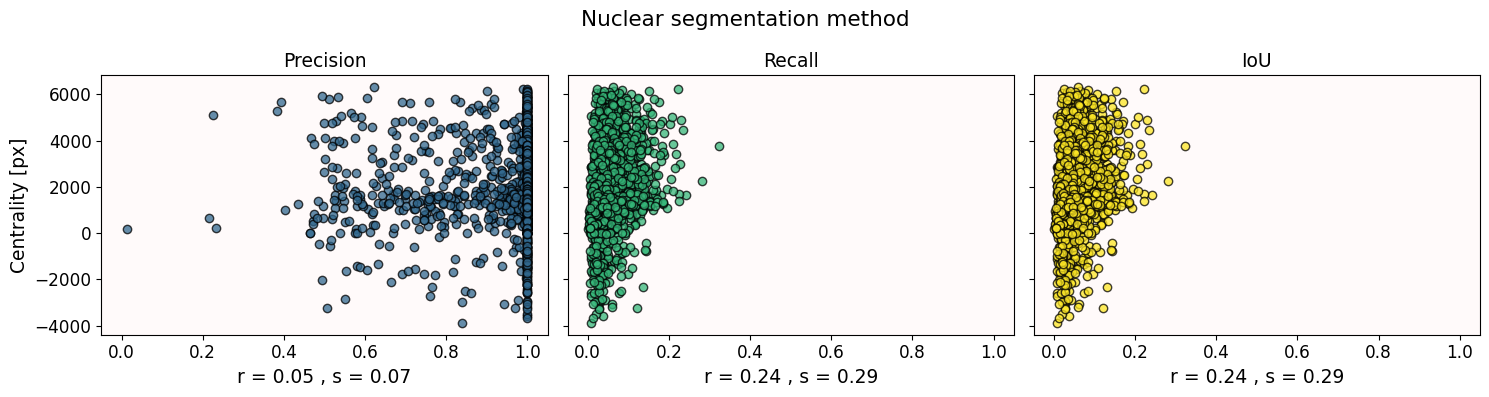

In [112]:
fig,ax = plt.subplots(1,3,figsize=(15,4), sharex=True, sharey=True)
yval = metaecc.loc[ df['putative'].to_numpy(), 'eccentricity']
for i,c in enumerate(['precision', 'recall', 'IoU']):
    pearson = stats.pearsonr(df[c], yval)
    spearman = stats.spearmanr(df[c], yval)

    ax[i].set_facecolor('snow')
    ax[i].set_title(c[0].upper() + c[1:], fontsize=fs)
    ax[i].scatter(df[c], yval, color=viridis(i+1), edgecolor='k', alpha=0.75)
    ax[i].tick_params(labelsize=0.9*fs)
    ax[i].set_xlabel('r = {:.2f} , s = {:.2f}'.format(pearson.statistic, spearman.statistic), fontsize=fs)
ax[0].set_ylabel('Centrality [px]', fontsize=fs)
fig.suptitle(ymethod.title() + ' segmentation method', fontsize=1.15*fs)
fig.tight_layout()
plt.savefig(dst + 'allcentrality_' + ymethod + fmt, **savefigkw)

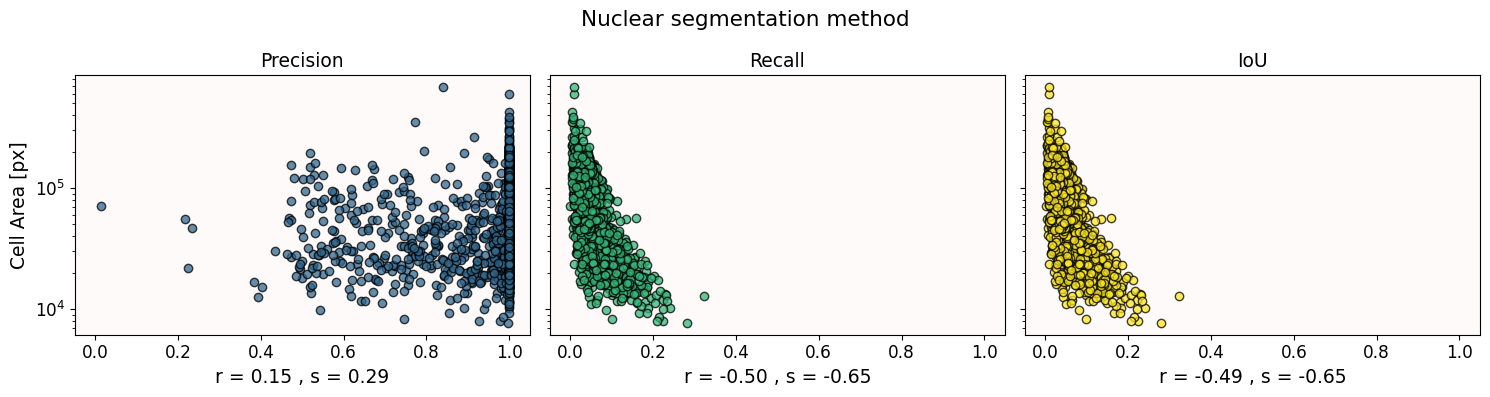

In [113]:
yval = metacell.loc[ df['putative'].to_numpy(), 'total_area']
fig,ax = plt.subplots(1,3,figsize=(15,4), sharex=True, sharey=True)

for i,c in enumerate(['precision', 'recall', 'IoU']):
    pearson = stats.pearsonr( df[c], yval)
    spearman = stats.spearmanr( df[c], yval)

    ax[i].set_facecolor('snow')
    ax[i].set_title(c[0].upper() + c[1:], fontsize=fs)
    ax[i].scatter( df[c], yval, color=viridis(i+1), edgecolor='k', alpha=0.75)
    ax[i].tick_params(labelsize=0.9*fs)
    ax[i].set_yscale('log',base=10)
    ax[i].set_xlabel('r = {:.2f} , s = {:.2f}'.format(pearson.statistic, spearman.statistic), fontsize=fs)
ax[0].set_ylabel('Cell Area [px]', fontsize=fs)
fig.suptitle(ymethod.title() + ' segmentation method', fontsize=1.15*fs)
fig.tight_layout()
plt.savefig(dst + 'allarea_' + ymethod + fmt, **savefigkw)

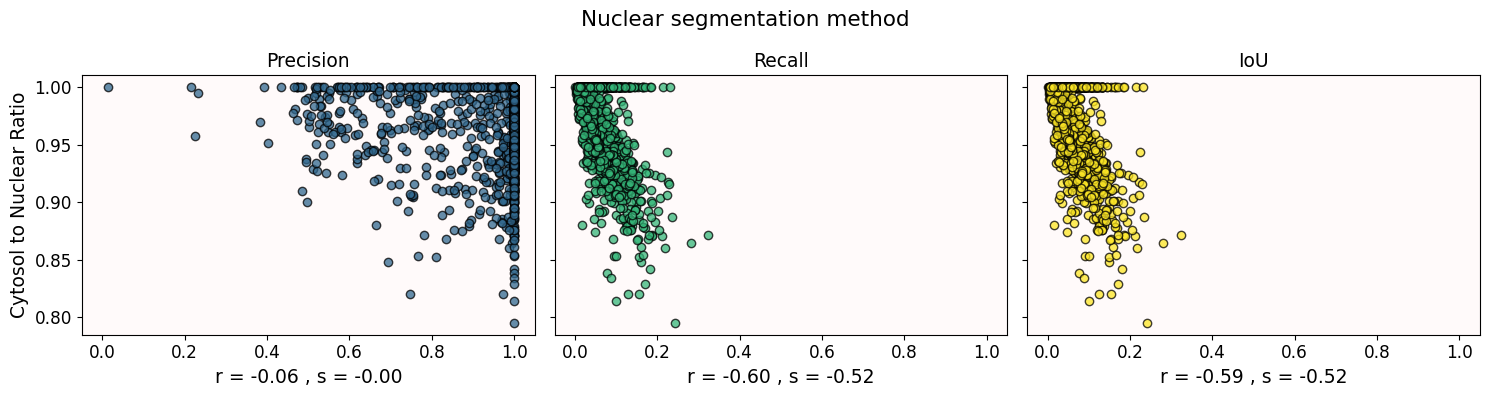

In [114]:
yval = metacell.loc[df['putative'].to_numpy(), 'c2t_area_ratio']
fig,ax = plt.subplots(1,3,figsize=(15,4), sharex=True, sharey=True)

for i,c in enumerate(['precision', 'recall', 'IoU']):
    pearson = stats.pearsonr( df[c], yval)
    spearman = stats.spearmanr( df[c], yval)

    ax[i].set_facecolor('snow')
    ax[i].set_title(c[0].upper() + c[1:], fontsize=fs)
    ax[i].scatter( df[c], yval, color=viridis(i+1), edgecolor='k', alpha=0.75)
    ax[i].tick_params(labelsize=0.9*fs)
    #ax[i].set_yscale('log',base=10)
    ax[i].set_xlabel('r = {:.2f} , s = {:.2f}'.format(pearson.statistic, spearman.statistic), fontsize=fs)
ax[0].set_ylabel('Cytosol to Nuclear Ratio', fontsize=fs)
fig.suptitle(ymethod.title() + ' segmentation method', fontsize=1.15*fs)
fig.tight_layout()

plt.savefig(dst + 'allc2nratio_' + ymethod + fmt, **savefigkw)

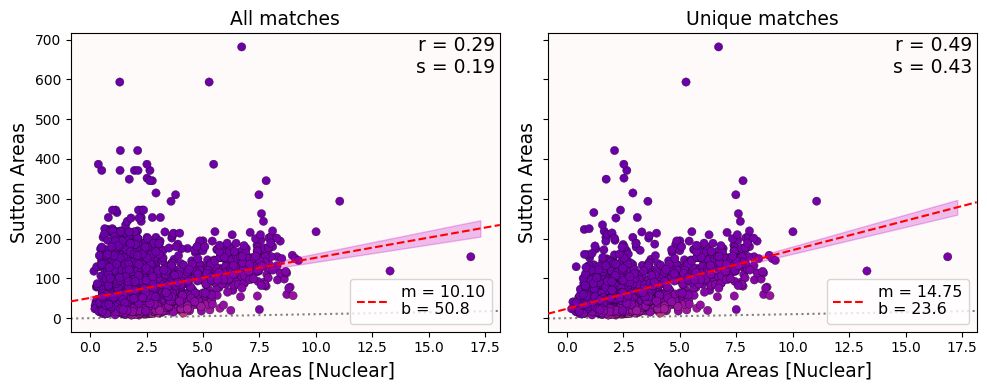

In [115]:
title = ['All matches', 'Unique matches']
fig,ax = plt.subplots(1,2,figsize=(10,4), sharex=True, sharey=True)
x = np.linspace(0, 1.025*newarea[1:].max(), 50)/1000

for i,data in enumerate([matched, nondup]):
    xval = newarea[data.index.to_numpy()]/1000
    yval = metacell.loc[ data['putative'].to_numpy(), 'total_area']/1000
    
    pearson = stats.pearsonr( xval, yval)
    spearman = stats.spearmanr( xval, yval)
    linregress = stats.linregress(xval, yval)
    ll = 'r = {:.2f}\ns = {:.2f}'.format(pearson.statistic, spearman.statistic)
    ax[i].text(0.99,0.99, ll, transform=ax[i].transAxes, ha='right', va='top', fontsize=fs, zorder=5)

    y = linregress.slope * x + linregress.intercept
    t = stats.t.ppf(0.975, len(xval) - 2)
    pred_y = linregress.slope * xval + linregress.intercept
    s = np.sqrt( np.sum( (yval - pred_y)**2)/(len(yval)-2) )
    sy = s * np.sqrt(1/(len(yval)) + ( x - np.mean(xval))**2 / np.sum((xval - np.mean(xval))**2))
    ci = t * sy
    
    ax[i].set_facecolor('snow')
    ax[i].set_title(title[i], fontsize=fs)
    ax[i].scatter(xval, yval, c=data['IoU'], cmap='plasma', ec='k', lw=0.2, vmin=-0.25, vmax=1, zorder=2)

    ll = 'm = {:.2f}\nb = {:.1f}'.format(linregress.slope, linregress.intercept)
    ax[i].axline( (0, linregress.intercept), slope=linregress.slope, ls='dashed', c='r', zorder=3, label=ll)
    ax[i].axline( (0,0), slope=1, ls='dotted', c='gray', zorder=1)
    
    ax[i].set_xlabel('Yaohua Areas [{}]'.format(ymethod.title()), fontsize=fs)
    ax[i].set_ylabel('Sutton Areas', fontsize=fs)
    ax[i].legend(loc='lower right', fontsize = 0.85*fs)
    ax[i].fill_between(x, y-ci, y+ci, alpha=0.25, color='m', zorder=2);

fig.tight_layout()
plt.savefig(dst + 'area_comparisons_' + ymethod + fmt, **savefigkw)

In [116]:
tmatch = dict()

for i,data in enumerate([matched, nondup]):
    t = pd.DataFrame(0, index=data.index, columns=['sutton', 'yaohua'])
    for ix in t.index:
        cidx = data.loc[ix, 'putative']
        t.loc[ix] = [ tsutton[cidx].sum(), tyaohua[ix].sum() ]
    tmatch[title[i]] = t[t.sum(axis = 1) > 0]

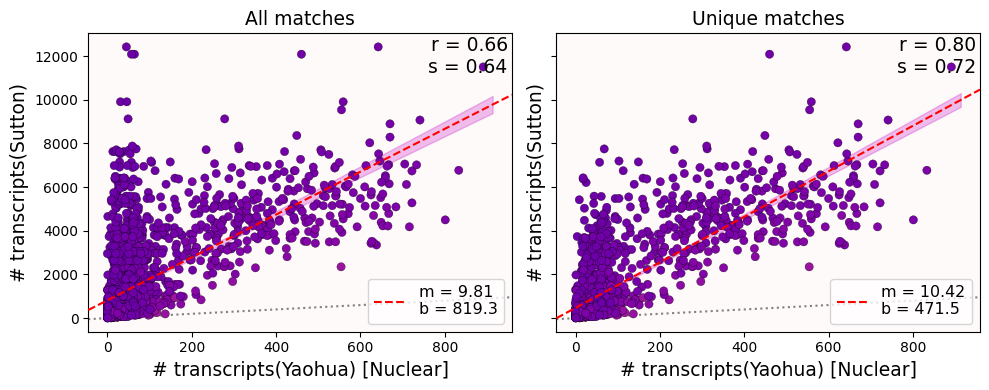

In [117]:
title = ['All matches', 'Unique matches']
fig,ax = plt.subplots(1,2,figsize=(10,4), sharex=True, sharey=True)
x = np.linspace(0, 1.025*tmatch[title[0]]['yaohua'].max(), 50)

for i,data in enumerate([matched, nondup]):    
    xval = tmatch[title[i]]['yaohua']
    yval = tmatch[title[i]]['sutton']
    
    pearson = stats.pearsonr( xval, yval)
    spearman = stats.spearmanr( xval, yval)
    linregress = stats.linregress(xval, yval)
    ll = 'r = {:.2f}\ns = {:.2f}'.format(pearson.statistic, spearman.statistic)
    ax[i].text(0.99,0.99, ll, transform=ax[i].transAxes, ha='right', va='top', fontsize=fs, zorder=5)

    y = linregress.slope * x + linregress.intercept
    t = stats.t.ppf(0.975, len(xval) - 2)
    pred_y = linregress.slope * xval + linregress.intercept
    s = np.sqrt( np.sum( (yval - pred_y)**2)/(len(yval)-2) )
    sy = s * np.sqrt(1/(len(yval)) + ( x - np.mean(xval))**2 / np.sum((xval - np.mean(xval))**2))
    ci = t * sy
    ax[i].fill_between(x, y-ci, y+ci, alpha=0.25, color='m', zorder=2)
    ax[i].axline( (0,0), slope=1, ls='dotted', c='gray', zorder=1);
    
    ax[i].set_facecolor('snow')
    ax[i].set_title(title[i], fontsize=fs)
    ax[i].scatter(xval, yval, c=data.loc[xval.index, 'IoU'], cmap='plasma', ec='k', lw=0.2, vmin=-0.25, vmax=1, zorder=2)

    ll = 'm = {:.2f}\nb = {:.1f}'.format(linregress.slope, linregress.intercept)
    ax[i].axline( (0, linregress.intercept), slope=linregress.slope, ls='dashed', c='r', zorder=3, label=ll)
    
    ax[i].set_xlabel('# transcripts(Yaohua) [{}]'.format(ymethod.title()), fontsize=fs)
    ax[i].set_ylabel('# transcripts(Sutton)', fontsize=fs)
    ax[i].legend(loc='lower right', fontsize = 0.85*fs)

fig.tight_layout()
plt.savefig(dst + 'transcriptcount_comparisons_' + ymethod + fmt, **savefigkw)

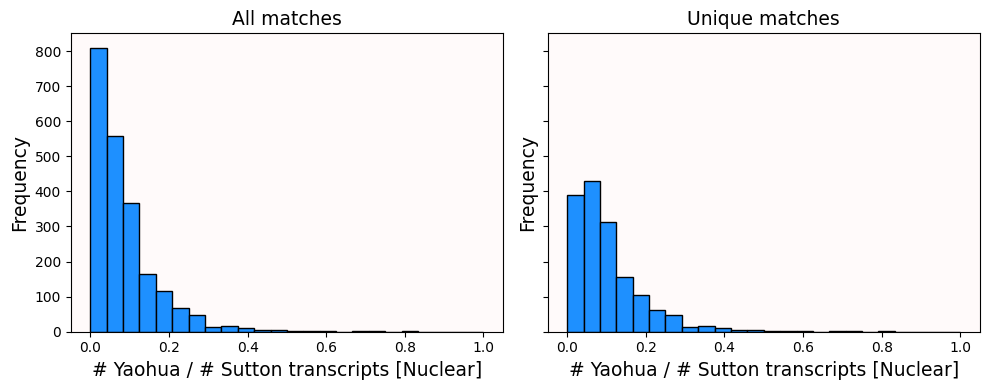

In [118]:
bins = np.linspace(0,1, 25)
fig,ax = plt.subplots(1,2,figsize=(10,4), sharex=True, sharey=True)

for i,data in enumerate([matched, nondup]):    
    xval = tmatch[title[i]]['yaohua']
    yval = tmatch[title[i]]['sutton']
    r = xval / yval
    r = r.where(r <= 1 , yval/xval)
    
    ax[i].set_facecolor('snow')
    ax[i].set_title(title[i], fontsize=fs)
    #ax[i].axvline(1, c='r', zorder=1)
    
    ax[i].hist(r , bins, color='dodgerblue', edgecolor='k', zorder=2)

    ax[i].set_xlabel('# Yaohua / # Sutton transcripts [{}]'.format(ymethod.title()), fontsize=fs)
    ax[i].set_ylabel('Frequency', fontsize=fs)
    
fig.tight_layout()
plt.savefig(dst + 'transcripthistogram_comparisons_' + ymethod + fmt, **savefigkw)

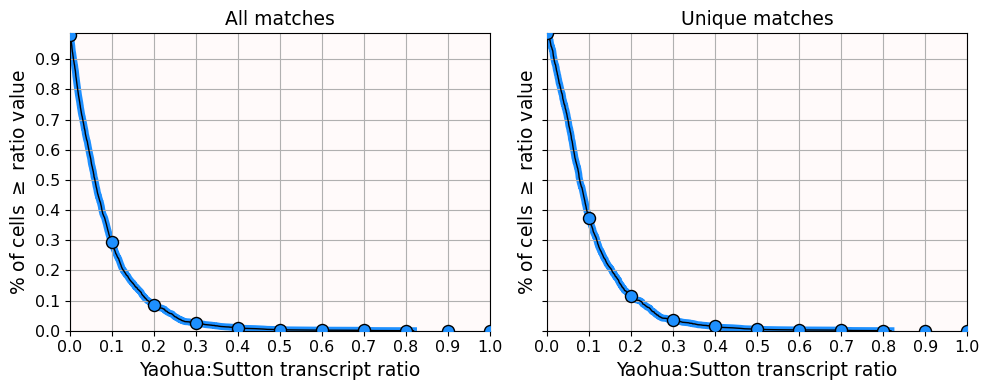

In [119]:
xvals = np.linspace(0,1,11)
fig,ax = plt.subplots(1,2,figsize=(10,4), sharex=True, sharey=True)

for i,data in enumerate([matched, nondup]):    
    xval = tmatch[title[i]]['yaohua']
    yval = tmatch[title[i]]['sutton']
    r = xval / yval
    r = r.where(r <= 1 , yval/xval)
    ecdf = stats.ecdf(r)
    
    ax[i].set_facecolor('snow')
    ax[i].set_title(title[i], fontsize=fs)
    
    ax[i].plot(ecdf.cdf.quantiles, 1-ecdf.cdf.probabilities, c='dodgerblue', lw=5, zorder=1)
    ax[i].plot(ecdf.cdf.quantiles, 1-ecdf.cdf.probabilities, c='k', lw=1, zorder=2)
    ax[i].scatter(xvals, 1-ecdf.cdf.evaluate(xvals), color='dodgerblue', ec='k', zorder=3, s=75)
    ax[i].tick_params(labelsize=0.85*fs)
    ax[i].set_xticks(xvals, np.round(xvals,1) )
    ax[i].set_yticks(xvals, np.round(xvals,1) )
    ax[i].grid(which='major')
    ax[i].margins(0)
    ax[i].set_xlabel('Yaohua:Sutton transcript ratio', fontsize=fs)
    ax[i].set_ylabel('% of cells $\\geq$ ratio value', fontsize=fs)
fig.tight_layout()

plt.savefig(dst + 'ecdf_transcript_distribution_' + ymethod + fmt, **savefigkw)

In [120]:
tmatches = dict()

for i,data in enumerate([matched, nondup]):
    tmatches[title[i]] = dict()
    for transcript in transcriptomes:
        t = pd.DataFrame(0, index=data.index, columns=['sutton', 'yaohua'])
        for ix in t.index:
            cidx = data.loc[ix, 'putative']
            t.loc[ix] = [ tsutton.loc[transcript , cidx], tyaohua.loc[transcript, ix] ]
        
        tmatches[title[i]][transcript] = t[t.sum(axis = 1) > 0]
    print(title[i])

All matches
Unique matches


In [121]:
t = transcriptomes[26]
tmatches[title[1]][t]
ts = tsutton.sum(axis=1).sort_values(ascending=False).index[:10]
ts

Index(['BAC47034', 'GLYMA_17G195900', 'GLYMA_05G092200', 'BAC52602',
       'GLYMA_12G027400', 'GLYMA_16G039800', 'BAC45727', 'GLYMA_11G008000',
       'GLYMA_05G216000', 'GLYMA_17G185800'],
      dtype='object', name='gene')

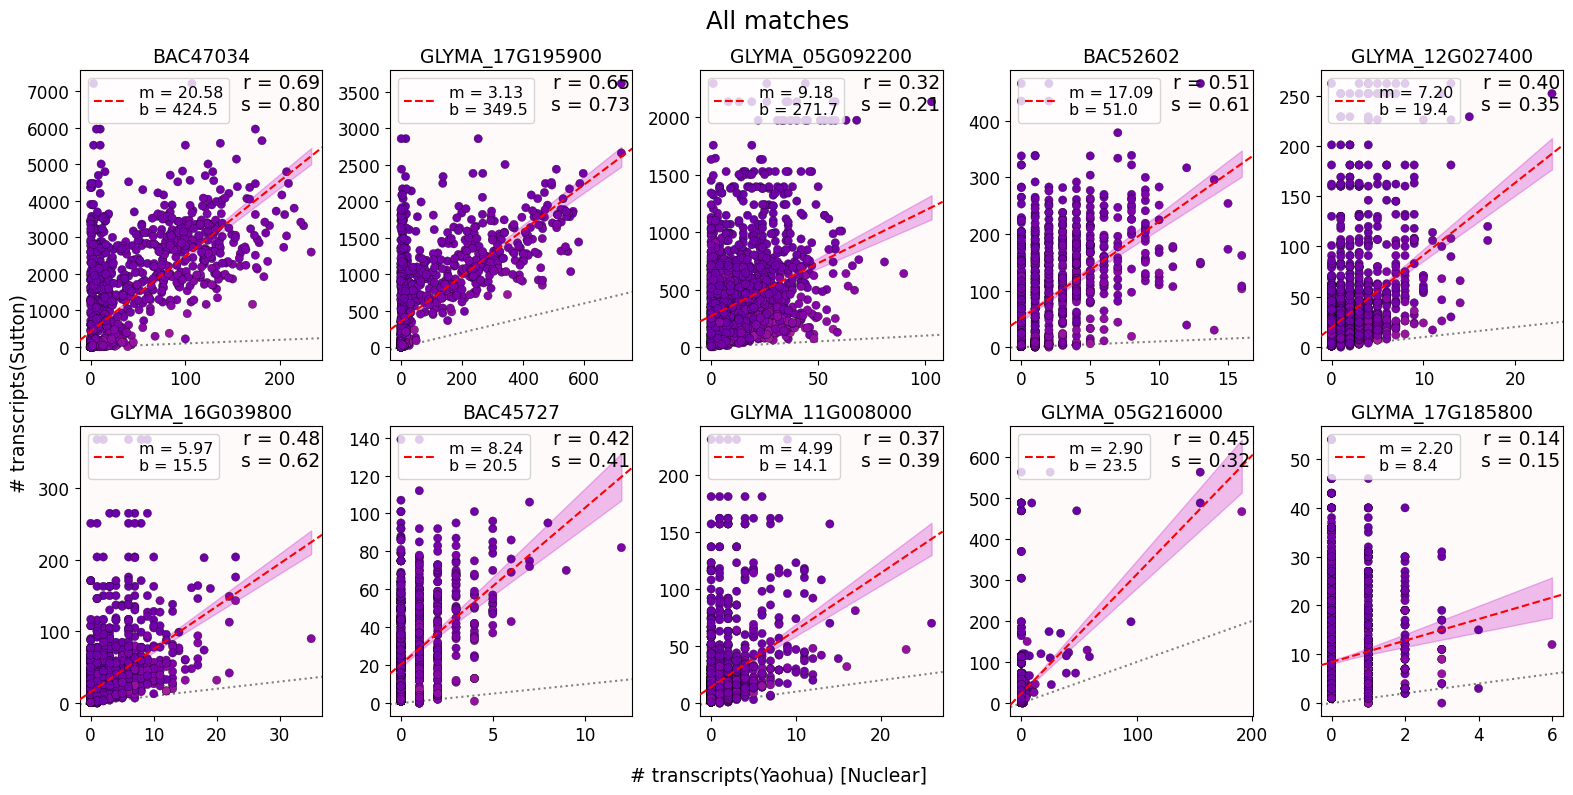

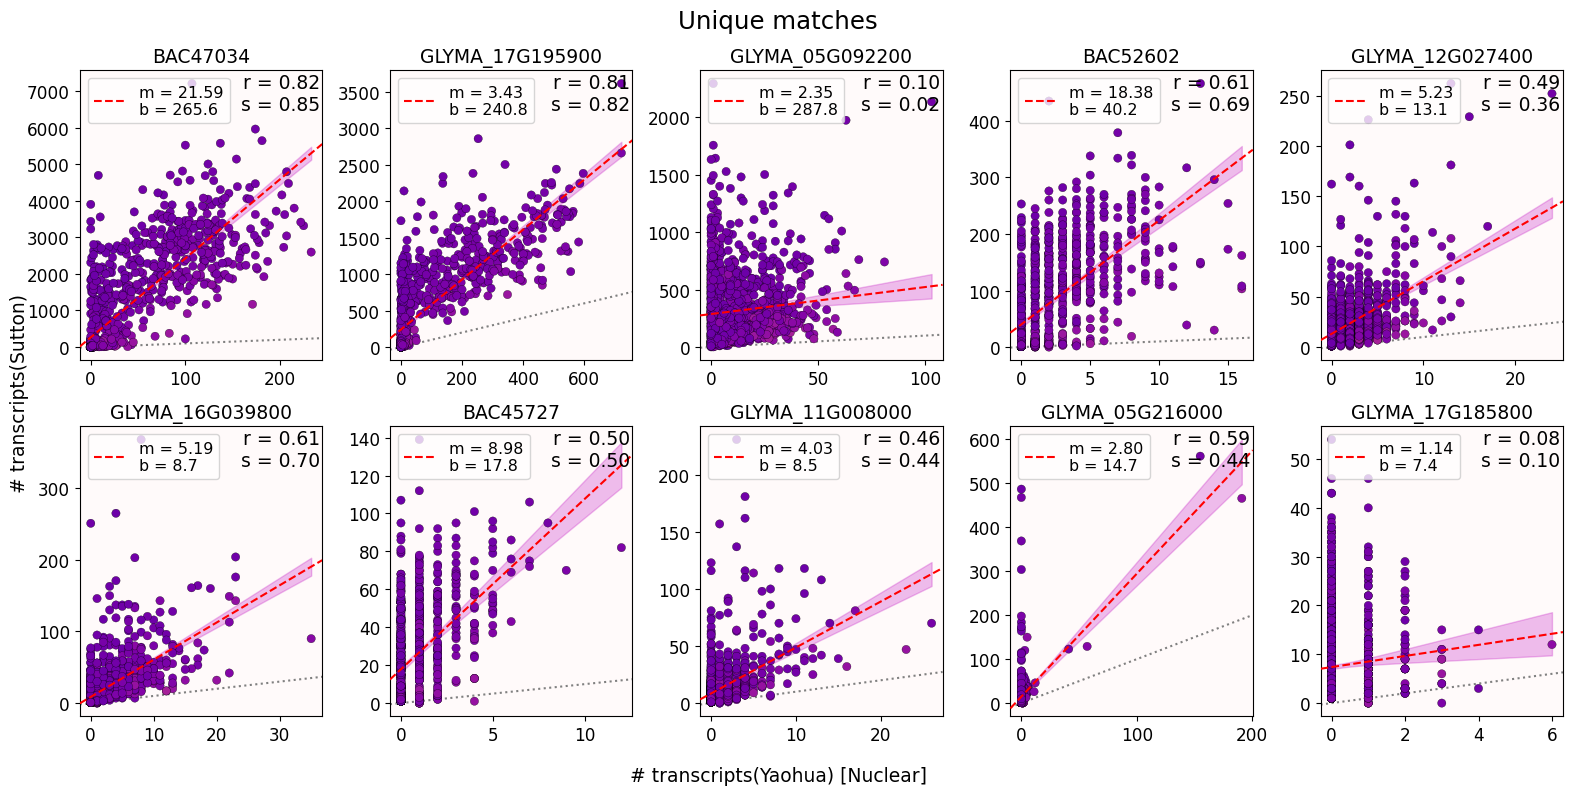

In [122]:
j = 1

for j,data in enumerate([matched, nondup]):
    fig,ax = plt.subplots(2, 5, figsize=(16,8), sharex=False, sharey=False)
    ax = ax.ravel()
    
    for i in range(len(ax)):    
        xval = tmatches[title[j]][ts[i]]['yaohua']
        yval = tmatches[title[j]][ts[i]]['sutton']

        x = np.linspace(0, xval.max(), 50)
        pearson = stats.pearsonr( xval, yval)
        spearman = stats.spearmanr( xval, yval)
        linregress = stats.linregress(xval, yval)
        ll = 'r = {:.2f}\ns = {:.2f}'.format(pearson.statistic, spearman.statistic)
        ax[i].text(0.99,0.99, ll, transform=ax[i].transAxes, ha='right', va='top', fontsize=fs, zorder = 5)

        y = linregress.slope * x + linregress.intercept
        t = stats.t.ppf(0.975, len(xval) - 2)
        pred_y = linregress.slope * xval + linregress.intercept
        s = np.sqrt( np.sum( (yval - pred_y)**2)/(len(yval)-2) )
        sy = s * np.sqrt(1/(len(yval)) + ( x - np.mean(xval))**2 / np.sum((xval - np.mean(xval))**2))
        ci = t * sy
        ax[i].fill_between(x, y-ci, y+ci, alpha=0.25, color='m', zorder=2)
        ax[i].axline( (0,0), slope=1, ls='dotted', c='gray', zorder=1);
        
        ax[i].set_facecolor('snow')
        ax[i].set_title(ts[i], fontsize=fs)
        ax[i].scatter(xval, yval, c=data.loc[xval.index, 'IoU'], cmap='plasma', ec='k', lw=0.2, vmin=-0.25, vmax=1, zorder=2)
    
        ll = 'm = {:.2f}\nb = {:.1f}'.format(linregress.slope, linregress.intercept)
        ax[i].axline( (0, linregress.intercept), slope=linregress.slope, ls='dashed', c='r', zorder=3, label=ll)
        ax[i].tick_params(labelsize=0.9*fs)
        ax[i].legend(loc='upper left', fontsize = 0.85*fs)
    
    fig.suptitle(title[j], fontsize=1.3*fs)
    fig.supxlabel('# transcripts(Yaohua) [{}]'.format(ymethod.title()), fontsize=fs)
    fig.supylabel('# transcripts(Sutton)', fontsize=fs)
        
    fig.tight_layout()
    plt.savefig(dst + 'individualgene_comparisons_' + title[j].replace(' ','_').lower() + '_' + ymethod + fmt, **savefigkw)

----
# Looking at nuclear masks

In [123]:
np.unique(ynuclei)

array([   0,    1,    2, ..., 2235, 2236, 2237], dtype=int32)

In [124]:
matched.loc[ dupidx ]

,putative,TP,FP,FN,IoU,precision,recall,f1
1,12,739,699,28920,0.024343,0.513908,0.024917,0.047529
18,11,502,0,143608,0.003483,1.000000,0.003483,0.006943
3,11,1262,0,142848,0.008757,1.000000,0.008757,0.017362
21,11,1683,0,142427,0.011679,1.000000,0.011679,0.023088
4,16,538,445,87823,0.006058,0.547304,0.006089,0.012043
...,...,...,...,...,...,...,...,...
2207,2863,947,0,178669,0.005272,1.000000,0.005272,0.010489
2202,2863,2764,1965,176852,0.015222,0.584479,0.015388,0.029987
2209,2863,3800,0,175816,0.021156,1.000000,0.021156,0.041436
2212,2884,1316,0,44386,0.028795,1.000000,0.028795,0.055979
